<a href="https://colab.research.google.com/github/giannaou13/giannaou13/blob/main/Week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [140]:
%config InlineBackend.figure_formats = ["retina"]

# Week 7: Migration and relocation

In [141]:
!pip install -q geopandas networkx us census xlrd

In [142]:
import json

import geopandas as gpd
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import requests
import us

from census import Census
from shapely.geometry import Point

In [143]:
census = Census("", year=2020)

In [144]:
state_code_to_abbr = { state.fips: state.abbr for state in us.states.STATES }
print(state_code_to_abbr)

{'01': 'AL', '02': 'AK', '04': 'AZ', '05': 'AR', '06': 'CA', '08': 'CO', '09': 'CT', '10': 'DE', '12': 'FL', '13': 'GA', '15': 'HI', '16': 'ID', '17': 'IL', '18': 'IN', '19': 'IA', '20': 'KS', '21': 'KY', '22': 'LA', '23': 'ME', '24': 'MD', '25': 'MA', '26': 'MI', '27': 'MN', '28': 'MS', '29': 'MO', '30': 'MT', '31': 'NE', '32': 'NV', '33': 'NH', '34': 'NJ', '35': 'NM', '36': 'NY', '37': 'NC', '38': 'ND', '39': 'OH', '40': 'OK', '41': 'OR', '42': 'PA', '44': 'RI', '45': 'SC', '46': 'SD', '47': 'TN', '48': 'TX', '49': 'UT', '50': 'VT', '51': 'VA', '53': 'WA', '54': 'WV', '55': 'WI', '56': 'WY'}


## ACS migration flows

We'll use New York again for our starting point!

In [145]:
state_fips = "36"

We're going to pull straight from `census.gov`, but we'll include a backup link in case federal data goes down again.

In [146]:
# alternate source (Musk-proofing): https://web.archive.org/web/20241226165446if_/https://www2.census.gov/programs-surveys/demo/tables/geographic-mobility/2020/county-to-county-migration-2016-2020/county-to-county-migration-flows/Net_Gross_US.txt

raw_flows = requests.get(
    "https://www2.census.gov/programs-surveys/demo/tables/geographic-mobility/2020/county-to-county-migration-2016-2020/county-to-county-migration-flows/Net_Gross_US.txt"
).content.decode("latin1").split("\n")

Let's take a look at the first row.

In [147]:
raw_flows[0]

'001001001003 Alabama                       Autauga County                      Alabama                       Baldwin County                            30       37      489      395     -459      396      519      398 '

OK so that's kind of messy.  It's not even a CSV (which is comma-separated), but rather it's tab-separated.  And it doesn't even have column headers.  We'll do a little sleuthing.  First, we poked around and found a spreadsheet with equivalent data, and used that to supply column header names.  Here they are.  

In [148]:
# column names we figured out from finding an equivalent Excel spreadsheet
place_columns = (
    "a_fips",
    "b_fips",
    "a_state",
    "a_county",
    "b_state",
    "b_county",
)

flow_columns = (
    "b_to_a_flow_est",
    "b_to_a_flow_moe",
    "a_to_b_flow_est",
    "a_to_b_moe",
    "net_flow_est",
    "net_flow_moe",
    "gross_flow_est",
    "gross_flow_moe",
)

columns = (*place_columns, *flow_columns)

The next two cells pull the data together into a dataframe that's suitable for studying flows.  The first one uses the spaces to split things up, in particular.

In [149]:
flows = []
for raw_flow in raw_flows[:-1]:
    flow_id = raw_flow[:raw_flow.index(" ")]
    if not all(c.isdigit() for c in flow_id):
        continue  # skip non-county flows

    assert len(flow_id) == 12, flow_id
    a_fips = flow_id[1:6]
    b_fips = flow_id[7:]

    remainder = raw_flow[raw_flow.index(" "):]
    parts = [a_fips, b_fips] + [part.strip() for part in remainder.split("  ") if part.strip()]
    flows.append({col: val for col, val in zip(columns, parts)})

In [150]:
flow_df = pd.DataFrame(flows).set_index(["a_fips", "b_fips"])
for col in flow_columns:
    flow_df[col] = flow_df[col].astype(int)

This next cell is just an assert statement to make sure there are no null values.  (We do this by summing a bunch of values and checking that the total isn't `NaN`.)

In [151]:
assert not flow_df["a_to_b_flow_est"].isna().sum()

Grab the borough/county names....

In [152]:
nyc_county_fips_codes = {
    "The Bronx": "36005",      # Bronx County
    "Brooklyn": "36047",       # Kings County
    "Manhattan": "36061",      # New York County
    "Queens": "36081",         # Queens County
    "Staten Island": "36085",  # Richmond
}

Now we read in a county shapefile (and put it in the Atlas Equal-Area CRS).

In [153]:
county_gdf = gpd.read_file("https://www2.census.gov/geo/tiger/TIGER2020/COUNTY/tl_2020_us_county.zip").set_index("GEOID").to_crs("EPSG:2163")

Let's narrow that gdf down to the NYC counties.  We have a dictionary where the county names are the keys, followed by FIPS codes as the values.  Let's list those values.

In [154]:
print(nyc_county_fips_codes.values())

dict_values(['36005', '36047', '36061', '36081', '36085'])


That functions as a list.  When we filter the geodataframe by that list, it will give us the rows with those FIPS codes.

In [155]:
nyc_county_gdf = county_gdf.loc[nyc_county_fips_codes.values()]

Now, make the graph!  remember `nx` means NetworkX, which is the basic Python library for graphs.

In [156]:
migration_graph = nx.DiGraph()
net_migration_graph = nx.DiGraph()

for a_county, a_county_fips in nyc_county_fips_codes.items():
    for b_county, b_county_fips in nyc_county_fips_codes.items():
        if a_county == b_county:
            continue

        flow = flow_df.loc[(a_county_fips, b_county_fips)]
        net_flow = flow["net_flow_est"]
        if net_flow >= 0:
            net_migration_graph.add_edge(
                a_county,
                b_county,
                weight=net_flow,
            )
        else:
            net_migration_graph.add_edge(
                b_county,
                a_county,
                weight=-net_flow,
            )

This next bit is a technical step.  We're using a Python library called `Shapely` that lets us manipulate geographical shapes.  This is grabbing the Shapely `point` object for each county's internal point and converting it to coordinates so that there's a mapped point associated with each object (county).

In [157]:
def cast_point(p):
    return (p.xy[0][0], p.xy[1][0])

Now, plot it!  We suppress the axes (because those aren't helpful here) and choose some plotting details, then draw the shapes, points, and arrows for flows.

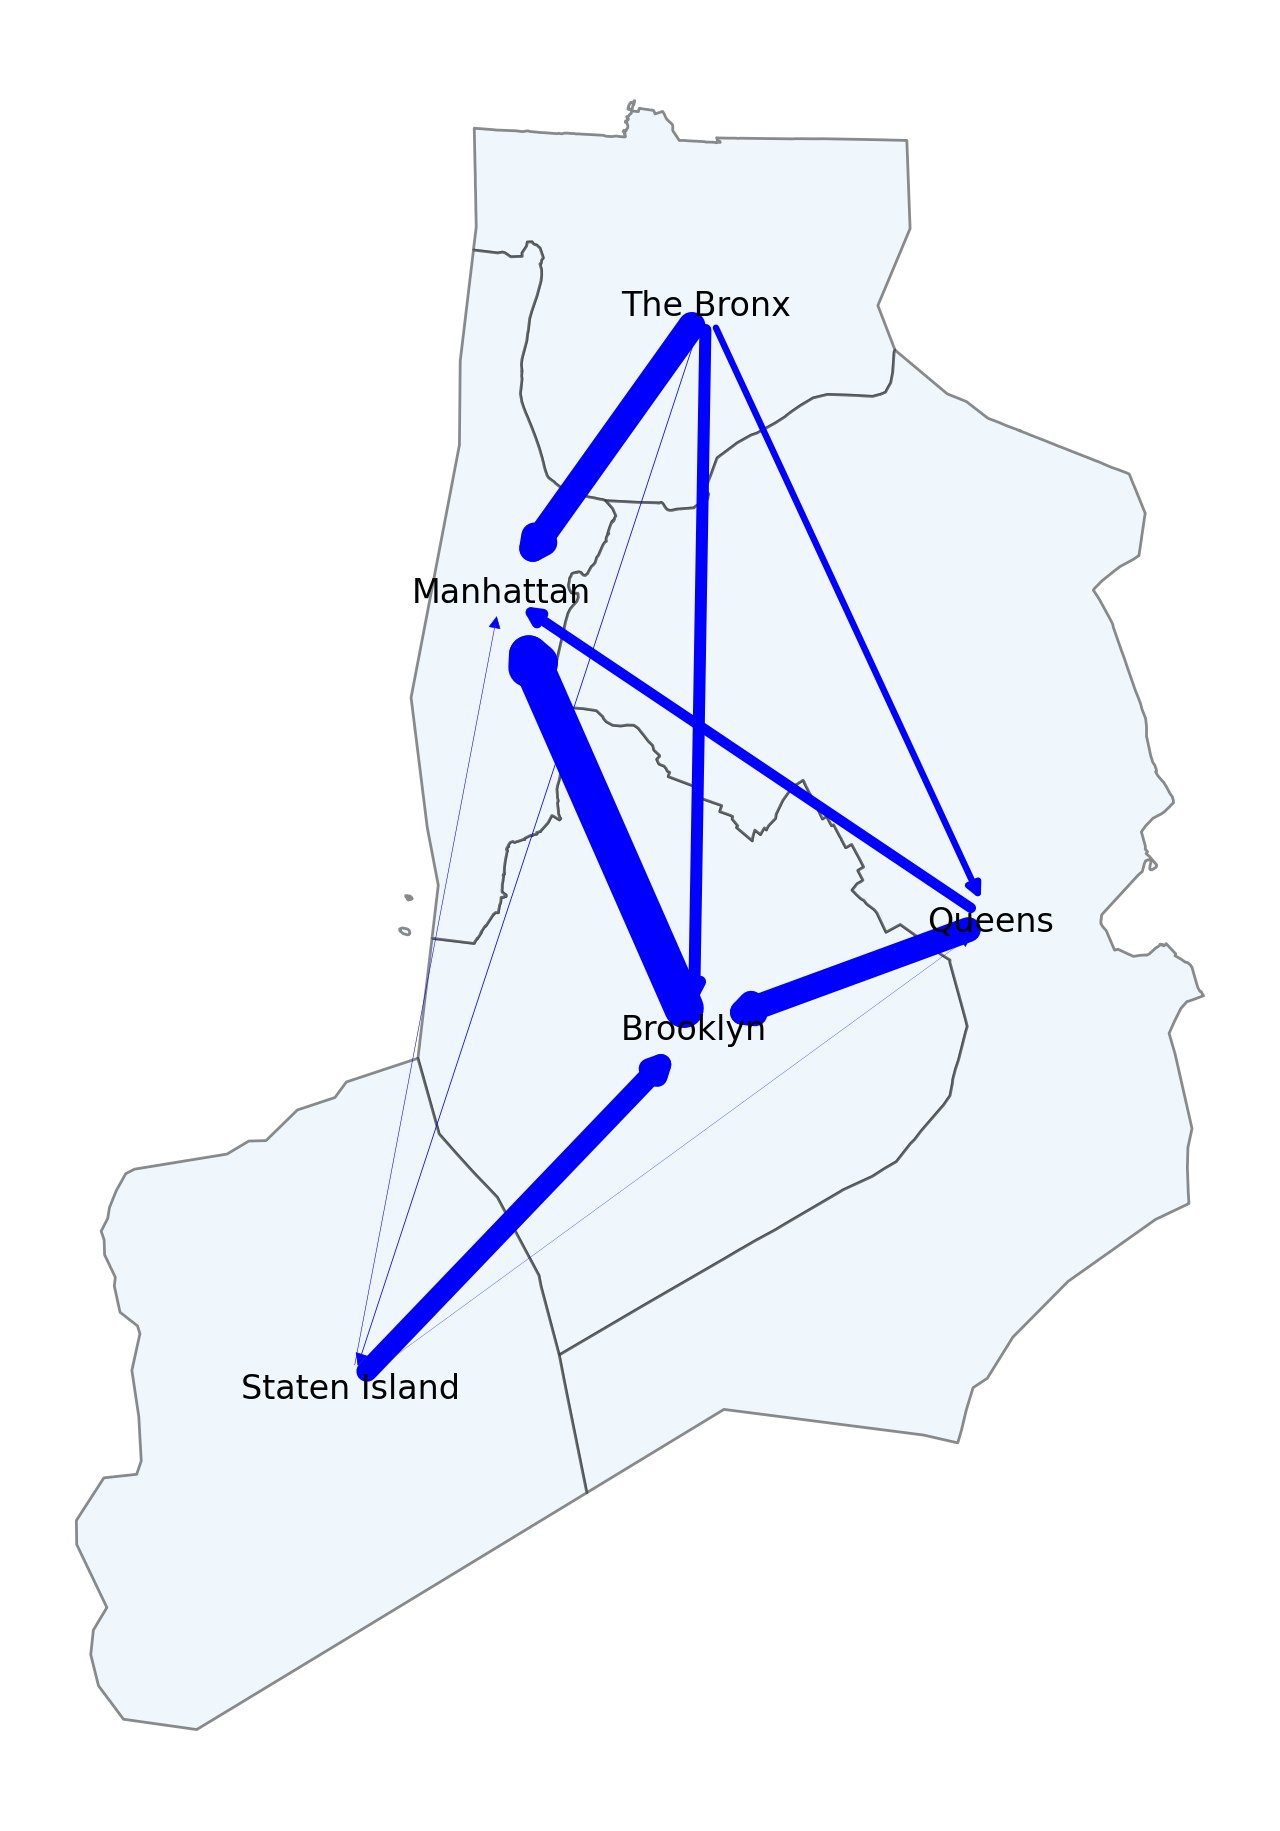

In [158]:
fig, ax = plt.subplots(figsize=(8, 16))
ax.axis("off")
nyc_county_gdf.plot(ax=ax, edgecolor="0.1", linewidth=1, color="#e1f1fd", alpha=0.5)

pos = {
    borough: cast_point(nyc_county_gdf.loc[county_fips].geometry.representative_point())
    for borough, county_fips in nyc_county_fips_codes.items()
}
#nx.draw_networkx_nodes(net_migration_graph, pos, ax=ax)
nx.draw_networkx_labels(net_migration_graph, pos, ax=ax)

for edge in net_migration_graph.edges(data='weight'):
    nx.draw_networkx_edges(net_migration_graph, pos, edgelist=[edge], width=0.0015 * edge[2], ax=ax, edge_color="blue")

# Migration with PUMS data

OK, so there's only so much we can do with the ACS data, which really is just numbers of people moving from one county to another.  If we want to drill down into race or other attributes, we should switch over to PUMS, or "public use microdata samples."  Let's pull in something called `rac1p` that records the correspondence between numerical codes found in the PUMS data and familiar race categories.

Important: PUMS is an extraordinary data source because since it's leveraging all the microdata, it lets you drill down way past these categories. Check out the [API docs](https://api.census.gov/data/2023/acs/acs1/pums/variables.html) for all the codes.  [RAC2P](https://api.census.gov/data/2023/acs/acs1/pums/variables/RAC2P.json) and [RAC3P](https://api.census.gov/data/2023/acs/acs1/pums/variables/RAC3P.json) are much more granular. But we're keeping it simple for now.

In [159]:
eng = {
    "0": "N/A (less than 5 years old/speaks only English)",
    "1": "Very well",
    "2": "Well",
    "3": "Not well",
    "4": "Not at all"
}

This next one will take a while (6 or 7 minutes or so in Colab). It populates the gdf with all the national data.  We'll have it print the state names as it processes them so we can get a kind of progress bar.

The geographical units for PUMS data are called [PUMAs](https://www.census.gov/programs-surveys/geography/guidance/geo-areas/pumas.html), or Public Use Microdata Areas.  

In [160]:
pums_results = []
puma_gdfs = []

for state in us.states.STATES:
    print(state)

    state_pums_response = requests.get(
        "https://api.census.gov/data/2023/acs/acs1/pums"
        f"?get=MIGSP,MIGPUMA,ENG&for=public%20use%20microdata%20area:*&in=state:{state.fips}"
    ).json()
    pums_results += state_pums_response[1:]

    puma_gdfs.append(
        gpd.read_file(
            f"https://www2.census.gov/geo/tiger/TIGER2024/PUMA20/tl_2024_{state.fips}_puma20.zip"
        )
    )

# Note that you could add in other variables from the PUMS data in the line above.  For instance, this alternative gets RAC3P as well as RAC1P.
#        f"?get=MIGSP,MIGPUMA,RAC1P,RAC3P&for=public%20use%20microdata%20area:*&in=state:{state.fips}"

Alabama
Alaska
Arizona
Arkansas
California
Colorado
Connecticut
Delaware
Florida
Georgia
Hawaii
Idaho
Illinois
Indiana
Iowa
Kansas
Kentucky
Louisiana
Maine
Maryland
Massachusetts
Michigan
Minnesota
Mississippi
Missouri
Montana
Nebraska
Nevada
New Hampshire
New Jersey
New Mexico
New York
North Carolina
North Dakota
Ohio
Oklahoma
Oregon
Pennsylvania
Rhode Island
South Carolina
South Dakota
Tennessee
Texas
Utah
Vermont
Virginia
Washington
West Virginia
Wisconsin
Wyoming


In [161]:
pumas_gdf = gpd.GeoDataFrame(pd.concat(puma_gdfs), crs=puma_gdfs[0].crs).set_index("GEOID20")

Still building the geodataframe -- one thing to notice is that we're using "internal points" provided by the Census Bureau as the location of the node associated to each PUMA.  (See [Census Glossary](https://www.census.gov/programs-surveys/geography/about/glossary.html))  These show up as `INTPLTLAT20` and `INTPTLON20`.

In [162]:
puma_points_gdf = gpd.GeoDataFrame(
    {
        "geometry": pumas_gdf.apply(
            lambda row: Point(float(row["INTPTLON20"]), float(row["INTPTLAT20"])),
            axis=1,
        ),
        "name": pumas_gdf["NAMELSAD20"],
        "lat": pumas_gdf["INTPTLAT20"].astype(float),
        "lon": pumas_gdf["INTPTLON20"].astype(float),
    },
    crs=pumas_gdf.crs,
)

In [163]:
puma_points_gdf

,geometry,name,lat,lon
GEOID20,,,,
0101700,POINT (-86.94619 32.40589),"Autauga, Dallas, Lowndes & Perry Counties PUMA",32.405885,-86.946190
0100100,POINT (-87.77501 34.6961),"Lauderdale, Colbert & Franklin Counties PUMA",34.696105,-87.775013
0100200,POINT (-86.9814 34.81024),Limestone County PUMA,34.810239,-86.981399
0101000,POINT (-87.3603 34.12802),"Cullman, Marion & Winston Counties PUMA",34.128017,-87.360304
0102400,POINT (-85.81365 31.41684),Coffee & Dale Counties PUMA,31.416840,-85.813651
...,...,...,...,...
5600100,POINT (-109.29807 43.96458),"Sheridan, Park, Teton, Lincoln & Big Horn Coun...",43.964580,-109.298071
5600200,POINT (-105.42705 43.65181),"Campbell, Goshen, Platte, Johnson, Washakie, W...",43.651810,-105.427053
5600300,POINT (-104.6604 41.29283),Laramie County PUMA,41.292830,-104.660395


In [164]:
excluded_migpumas = (
    "00001",  # Did not live in the United States or in Puerto Rico one year ago
    "00002",  # Lived in Puerto Rico one year ago and current residence is in the United States
    "N",      # N/A (person less than 1 year old/lived in same house 1 year ago)
)

In [165]:
puma_df = pd.DataFrame(pums_results, columns=["migsp", "migpuma", "eng", "state", "puma"])
puma_df["eng"] = puma_df["eng"].map(eng)

# If you wanted more variables from PUMS, you can do that something like this.
# puma_df = pd.DataFrame(pums_results, columns=["migsp", "migpuma", "rac1p", "rac3p" "state", "puma"])
# puma_df["rac1p"] = puma_df["rac1p"].map(rac1p) # codes -> labels
# puma_df["rac3p"] = puma_df["rac3p"].map(rac3p) # likewise, codes -> labels
puma_df

,migsp,migpuma,eng,state,puma
0,N,N,N/A (less than 5 years old/speaks only English),01,02803
1,N,N,N/A (less than 5 years old/speaks only English),01,00402
2,N,N,N/A (less than 5 years old/speaks only English),01,01403
3,N,N,N/A (less than 5 years old/speaks only English),01,01403
4,N,N,N/A (less than 5 years old/speaks only English),01,02600
...,...,...,...,...,...
3399069,N,N,N/A (less than 5 years old/speaks only English),56,00400
3399070,N,N,N/A (less than 5 years old/speaks only English),56,00300
3399071,N,N,N/A (less than 5 years old/speaks only English),56,00500
3399072,N,N,N/A (less than 5 years old/speaks only English),56,00500


In [166]:
puma_flows_df = puma_df[puma_df["migsp"].str.startswith("0")].copy()
puma_flows_df["from"] = puma_flows_df["migsp"].str.slice(1) + puma_flows_df["migpuma"]
puma_flows_df["to"] = puma_df["state"] + puma_flows_df["puma"]
puma_flows_df = puma_flows_df[["from", "to", "eng"]]
puma_flows_df

,from,to,eng
22,1301300,0100700,N/A (less than 5 years old/speaks only English)
23,0100490,0100402,N/A (less than 5 years old/speaks only English)
24,0100490,0100402,N/A (less than 5 years old/speaks only English)
25,0100490,0100402,N/A (less than 5 years old/speaks only English)
36,0100490,0101404,N/A (less than 5 years old/speaks only English)
...,...,...,...
3399032,0801000,5600300,N/A (less than 5 years old/speaks only English)
3399049,5600400,5600300,N/A (less than 5 years old/speaks only English)
3399050,5600400,5600300,N/A (less than 5 years old/speaks only English)
3399064,4201700,5600200,N/A (less than 5 years old/speaks only English)


In [167]:
state_gdf = gpd.read_file("https://www2.census.gov/geo/tiger/TIGER2024/STATE/tl_2024_us_state.zip").set_index("GEOID").to_crs("EPSG:2163")

In [168]:
proj_puma_points = dict(puma_points_gdf.to_crs("EPSG:2163")["geometry"])

In [169]:
# Filter for low-fluency migrants (codes 3 and 4) and exclude N/A (0)
low_fluency_df = puma_flows_df[
    (puma_flows_df["eng"].isin(["Not well", "Not at all"]))  # Keep "Not well" and "Not at all"
    & (puma_flows_df["eng"] != "N/A (less than 5 years old/speaks only English)")  # Exclude N/A
].copy()

# Check the filtered DataFrame
print("Number of rows in low_fluency_df:", len(low_fluency_df))
print(low_fluency_df.head())

# Extract state codes from "from" and "to" columns (first 2 characters)
low_fluency_df["origin_state"] = low_fluency_df["from"].str[:2]  # Origin state (e.g., "06" for CA)
low_fluency_df["dest_state"] = low_fluency_df["to"].str[:2]      # Destination state (e.g., "48" for TX)

# Aggregate out-migration (loss) and in-migration (gain) by state
out_migration = low_fluency_df.groupby("origin_state").size().reset_index(name="out_count")
in_migration = low_fluency_df.groupby("dest_state").size().reset_index(name="in_count")

# Merge and calculate net migration
migration_net = pd.merge(
    out_migration.rename(columns={"origin_state": "state_code"}),
    in_migration.rename(columns={"dest_state": "state_code"}),
    on="state_code",
    how="outer"
).fillna(0)

migration_net["net"] = migration_net["in_count"] - migration_net["out_count"]
migration_net["state"] = migration_net["state_code"].map(state_code_to_abbr)
migration_net = migration_net[["state", "net"]]
print(migration_net)

Number of rows in low_fluency_df: 9939
         from       to         eng
1936  1209500  0100403    Not well
2742  5326700  0100300    Not well
6896  0100100  0100100  Not at all
6897  0100100  0100100    Not well
7026  0102300  0101802    Not well
   state   net
0     AL  -7.0
1     AK   0.0
2     AZ  -3.0
3     AR  -2.0
4     CA -52.0
5     CO  12.0
6     CT  -3.0
7     DE   7.0
8    NaN  -3.0
9     FL  -6.0
10    GA  23.0
11    HI   3.0
12    ID   1.0
13    IL  -3.0
14    IN  12.0
15    IA   5.0
16    KS   3.0
17    KY   5.0
18    LA  -2.0
19    ME   0.0
20    MD -22.0
21    MA  -1.0
22    MI   3.0
23    MN   2.0
24    MS   5.0
25    MO   1.0
26    MT   0.0
27    NE   2.0
28    NV  18.0
29    NH   2.0
30    NJ   0.0
31    NM  12.0
32    NY -59.0
33    NC  22.0
34    ND  -2.0
35    OH  -5.0
36    OK  -2.0
37    OR   4.0
38    PA   8.0
39    RI   5.0
40    SC  16.0
41    SD  -1.0
42    TN  10.0
43    TX  58.0
44    UT  -1.0
45    VT  -2.0
46    VA   8.0
47    WA   3.0
48    WV  -1.0
4

In [170]:
import plotly.express as px

# Create the choropleth map
fig = px.choropleth(
    migration_net,
    locations="state",
    locationmode="USA-states",
    color="net",
    scope="usa",
    color_continuous_scale="Blues",  # Changed color scheme to "Viridis"
    range_color=[-70, 70],  # Set a smaller scale for the color axis
    title="Net Migration of Low-Fluency English Speakers",
    hover_data={"net": ":.0f", "state": True},
    labels={"net": "Net Gain (blue) and Loss (red)"},
    height=600
)

# Customize the layout
fig.update_layout(
    geo=dict(bgcolor='rgba(0,0,0,0)'),  # Transparent background
    coloraxis_colorbar=dict(
        title="Net Migration",  # Color bar title
        tickvals=[-70, 0, 70],  # Custom tick values
        ticktext=["-70", "0", "70"]  # Custom tick labels
    )
)

# Show the plot
fig.show()

Let's take a look at flows in and out of one state in a static map.  We'll choose California (FIPS code 06).

In [171]:
# Filter for high-fluency migrants
high_fluency_df = puma_flows_df[
    (puma_flows_df["eng"].isin(["Very well", "Well"]))  # Keep "Very well" and "Well"
    & (puma_flows_df["eng"] != "N/A (less than 5 years old/speaks only English)")  # Exclude N/A
].copy()

# Check the filtered DataFrame
print("Number of rows in high_fluency_df:", len(high_fluency_df))
print(high_fluency_df.head())

# Extract state codes from "from" and "to" columns
high_fluency_df["origin_state"] = high_fluency_df["from"].str[:2]  # Origin state (e.g., "06" for CA)
high_fluency_df["dest_state"] = high_fluency_df["to"].str[:2]      # Destination state (e.g., "48" for TX)

# Check the extracted state codes
print(high_fluency_df[["from", "origin_state", "to", "dest_state"]].head())
# Aggregate out-migration (loss) by origin state
out_migration = high_fluency_df.groupby("origin_state").size().reset_index(name="out_count")

# Aggregate in-migration (gain) by destination state
in_migration = high_fluency_df.groupby("dest_state").size().reset_index(name="in_count")

# Check the aggregated DataFrames
print("Out-migration:")
print(out_migration.head())
print("In-migration:")
print(in_migration.head())
# Merge out/in counts and calculate net migration
migration_net = pd.merge(
    out_migration.rename(columns={"origin_state": "state_code"}),
    in_migration.rename(columns={"dest_state": "state_code"}),
    on="state_code",
    how="outer"
).fillna(0)

migration_net["net"] = migration_net["in_count"] - migration_net["out_count"]
migration_net["state"] = migration_net["state_code"].map(state_code_to_abbr)
migration_net = migration_net[["state", "net"]]
print(migration_net)

Number of rows in high_fluency_df: 55490
        from       to        eng
154  0100800  0100800  Very well
215  0100490  0100403  Very well
217  0100490  0100403       Well
458  3604300  0101404  Very well
881  3800200  0101801  Very well
        from origin_state       to dest_state
154  0100800           01  0100800         01
215  0100490           01  0100403         01
217  0100490           01  0100403         01
458  3604300           36  0101404         01
881  3800200           38  0101801         01
Out-migration:
  origin_state  out_count
0           01        247
1           02        139
2           04       1521
3           05        217
4           06      11961
In-migration:
  dest_state  in_count
0         01       240
1         02       148
2         04      1563
3         05       199
4         06     11699
   state    net
0     AL   -7.0
1     AK    9.0
2     AZ   42.0
3     AR  -18.0
4     CA -262.0
5     CO   89.0
6     CT  -16.0
7     DE    8.0
8    NaN -102.0
9 

In [172]:
import plotly.express as px

# Create the choropleth map
fig = px.choropleth(
    migration_net,
    locations="state",
    locationmode="USA-states",
    color="net",
    scope="usa",
    color_continuous_scale="Blues",  # Changed color scheme to "Blues"
    range_color=[-500, 500],  # Set a smaller scale for the color axis
    title="Net Migration of High-Fluency English Speakers",
    hover_data={"net": ":.0f", "state": True},
    labels={"net": "Net Gain (dark blue) and Loss (light blue)"},
    height=600
)

# Customize the layout
fig.update_layout(
    geo=dict(bgcolor='rgba(0,0,0,0)'),  # Transparent background
    coloraxis_colorbar=dict(
        title="Net Migration",  # Color bar title
        tickvals=[-500, 0, 500],  # Custom tick values
        ticktext=["-500", "0", "500"]  # Custom tick labels
    )
)

# Show the plot
fig.show()

In [173]:
flow_state = "06"

In [174]:
for race in puma_flows_df["race"].unique():
        race_flows_df = puma_flows_df[puma_flows_df["race"] == race]
        in_flow_counts = race_flows_df[race_flows_df["to"].str.startswith(flow_state)].groupby(by=["from", "to"]).size()
        out_flow_counts = race_flows_df[race_flows_df["from"].str.startswith(flow_state)].groupby(by=["from", "to"]).size()

        ax = state_gdf.plot(
            figsize=(20, 10),
            edgecolor="0.1",
            linewidth=0.4,
            color="#e1f1fd",
        )

        for flow_counts, color in zip((in_flow_counts, out_flow_counts), ("red", "blue")):
            for (flow_from, flow_to), count in flow_counts.items():
                try:
                    from_x, from_y = proj_puma_points[flow_from].coords.xy
                    to_x, to_y = proj_puma_points[flow_to].coords.xy
                except KeyError:
                    continue

                ax.plot([from_x[0], to_x[0]], [from_y[0], to_y[0]], color=color, linewidth=0.5 * count, alpha=0.3)

        ax.axis("off")
        ax.set_title(f"{race} migration (in: red, out: blue)")
        plt.show()

KeyError: 'race'

## Let's make a FlowmapBlue

Same as before, we'll set up some Google credentials to use with FlowmapBlue.

In [ ]:
!pip install "git+https://github.com/PUBPOL-2130/notebooks#egg=pubpol2130&subdirectory=lib"

In [ ]:
from pubpol2130 import google_sheets_credentials, generate_flow_sheet

In [ ]:
sheet_creds = google_sheets_credentials()

### ACS + FlowmapBlue

In [ ]:
county_flowmap_locations_df = county_gdf[["NAMELSAD", "INTPTLON", "INTPTLAT"]].reset_index().rename(
    columns={"NAMELSAD": "name", "INTPTLON": "lon", "INTPTLAT": "lat", "GEOID": "id"}
)
county_flowmap_locations_df

In [ ]:
a_to_b_acs_flow_counts = flow_df.reset_index()[["a_fips", "b_fips", "a_to_b_flow_est"]].rename(
    columns={"a_fips": "origin", "b_fips": "dest", "a_to_b_flow_est": "count"}
)
b_to_a_acs_flow_counts = flow_df.reset_index()[["a_fips", "b_fips", "b_to_a_flow_est"]].rename(
    columns={"b_fips": "origin", "a_fips": "dest", "b_to_a_flow_est": "count"}
)
acs_flow_counts = pd.concat([a_to_b_acs_flow_counts, b_to_a_acs_flow_counts])

Making the flow sheet takes 1-2 minutes.

In [ ]:
acs_flow_sheet = generate_flow_sheet(
    sheet_creds=sheet_creds,
    locations_df=county_flowmap_locations_df.sort_values(by=["id"]),
    sheet_title="PUBPOL 2130: ACS migration flows",
    flow_title="U.S. Census ACS county-to-county migration flows, 2016-2020",
    incoming_tooltip="People in",
    outgoing_tooltip="People out",
    flow_tooltip="People",
    total_unit="people",
    data_source_name="U.S. Census ACS county-to-county migration flows, 2016-2020",
    data_source_url="https://www.census.gov/programs-surveys/acs",
    flows={"2016-2020": acs_flow_counts},
)

In [ ]:
print(acs_flow_sheet.url)

In [ ]:
print(f"https://www.flowmap.blue/{acs_flow_sheet.url.split('/')[-1]}")

#### Aggregating up to the state level

In [ ]:
state_flowmap_locations_df = state_gdf[["NAME", "INTPTLON", "INTPTLAT"]].reset_index().rename(
    columns={"NAME": "name", "INTPTLON": "lon", "INTPTLAT": "lat", "GEOID": "id"}
)

In [ ]:
state_acs_flow_counts = acs_flow_counts.copy()
state_acs_flow_counts["origin"] = state_acs_flow_counts["origin"].str[:2]
state_acs_flow_counts["dest"] = state_acs_flow_counts["dest"].str[:2]
state_acs_flow_counts = state_acs_flow_counts.groupby(by=["origin", "dest"]).sum().reset_index()

# Exclude intra-state flows.
state_acs_flow_counts = state_acs_flow_counts[
    state_acs_flow_counts["origin"] != state_acs_flow_counts["dest"]
]
state_acs_flow_counts

In [ ]:
state_acs_flow_sheet = generate_flow_sheet(
    sheet_creds=sheet_creds,
    locations_df=state_flowmap_locations_df,
    sheet_title="PUBPOL 2130: ACS migration flows (interstate)",
    flow_title="U.S. Census ACS interstate migration flows, 2016-2020",
    incoming_tooltip="People in",
    outgoing_tooltip="People out",
    flow_tooltip="People",
    total_unit="people",
    data_source_name="U.S. Census ACS state-to-state migration flows, 2016-2020",
    data_source_url="https://www.census.gov/programs-surveys/acs",
    flows={"2016-2020": state_acs_flow_counts},
)

In [ ]:
print(state_acs_flow_sheet.url)

In [ ]:
print(f"https://www.flowmap.blue/{state_acs_flow_sheet.url.split('/')[-1]}")

### PUMS + FlowmapBlue

In [ ]:
migpuma_by_puma_df = pd.read_excel("https://usa.ipums.org/usa/resources/volii/puma_migpuma1_pwpuma00_2020.xls", dtype=str)

migpuma_by_puma_df["puma_geoid"] = (
    migpuma_by_puma_df["State of Residence (ST)"]
    + migpuma_by_puma_df["PUMA"]
)

migpuma_by_puma_df["migpuma_geoid"] = (
    migpuma_by_puma_df["Place of Work State (PWSTATE2) or Migration State (MIGPLAC1)"]
    + migpuma_by_puma_df["PWPUMA00 or MIGPUMA1"]
).str[1:]

migpuma_by_puma_df = migpuma_by_puma_df[["puma_geoid", "migpuma_geoid"]].set_index("migpuma_geoid").sort_values(by="puma_geoid")

In [ ]:
exclude_migpumas = {"7200002", "1100100"}
exclude_pumas = {"1100101"}

In [ ]:
puma_flowmap_locations_df = puma_points_gdf.drop(columns=["geometry"])
puma_flowmap_locations_df.index.names = ["id"]
puma_flowmap_locations_df

In [ ]:
# For the purposes of visualization, arbitrarily assign ambiguous MIGPUMAs to the
# first corresponding PUMA (in lexographic order).
missing_migpumas = (set(puma_flows_df["from"]) | set(puma_flows_df["to"])) - set(proj_puma_points)
migpuma_rows = []

for missing_migpuma in missing_migpumas - exclude_migpumas:
    puma_geoid = migpuma_by_puma_df.loc[missing_migpuma].iloc[0]["puma_geoid"]
    if puma_geoid in exclude_pumas:
        continue

    migpuma_rows.append({
        "id": missing_migpuma,
        **puma_flowmap_locations_df.loc[puma_geoid],
    })

puma_flowmap_locations_df = pd.concat([
    puma_flowmap_locations_df,
    pd.DataFrame(migpuma_rows).set_index("id"),
])

In [ ]:
filtered_puma_flows_df = puma_flows_df[
    ~puma_flows_df["from"].isin(exclude_migpumas)
    & ~puma_flows_df["to"].isin(exclude_pumas)
]

In [ ]:
display_names = {
    "white": "White",
    "black": "Black or African American",
    "amin": "American Indian or Alaska Native",
    "aapi": "Asian; Native Hawaiian or Other Pacific Islander",
    "other": "Some Other Race",
    "two_or_more": "Two or More Races",
}

In [ ]:
puma_flows_df

In [ ]:
flows_by_race = {}

for race in puma_flows_df["race"].unique():
        race_flows_df = filtered_puma_flows_df[filtered_puma_flows_df["race"] == race].groupby(
            by=["from", "to"]
        ).size()
        flows_by_race[display_names[race]] = race_flows_df.reset_index().rename(
            columns={"from": "origin", "to": "dest", 0: "count"}
        )

This one takes about 2 minutes.

In [ ]:
flow_by_race_sheet = generate_flow_sheet(
    sheet_creds=sheet_creds,
    locations_df=puma_flowmap_locations_df.reset_index(),
    sheet_title="PUBPOL 2130: PUMS migration flows",
    flow_title="U.S. Census PUMS migration flows, 2023",
    incoming_tooltip="People in",
    outgoing_tooltip="People out",
    flow_tooltip="People",
    total_unit="people",
    data_source_name="U.S. Census PUMS migration flows, 2023",
    data_source_url="https://www.census.gov/programs-surveys/acs/microdata.html",
    flows=flows_by_race,
)

In [ ]:
print(flow_by_race_sheet.url)

In [ ]:
print(f"https://www.flowmap.blue/{flow_by_race_sheet.url.split('/')[-1]}")

#Homework 6, due Tuesday March 18, 1:25pm

First, a warmup question.  How many American Indian/Native American people moved from New York State to Oklahoma in 2018?  Briefly explain how you figured it out.

Then, the usual:  use the ACS migration matrix or the PUMS resources to drill down to an interesting question.  Explain how you are using the methods here to suggest the question and approach answering it.  Create a data product that addresses your question.



**Reading question**:  Our migration reading is by Enrico Moretti, writing about "The Inequality of Mobility and Cost of Living."  His chapter has many claims about how education policy, employment policy, and housing policy influence (and are influenced by) human migration within the U.S.  Choose one claim from the chapter (please cite the claim and the page you found it on), and explain how you could use geospatial data to investigate Moretti's argument.  